In [6]:
import pandas as pd

df = pd.read_csv("loan_data.csv")

print(df.head())
print(df.info())
print(df.describe())




   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561  

What you should observe 

You should start noticing:

Missing values
Categorical columns (Gender, Education, etc.)
Target variable: Loan_Status

In [7]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Rudraksh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
print(df['loan_status'].value_counts())

loan_status
0    35000
1    10000
Name: count, dtype: int64


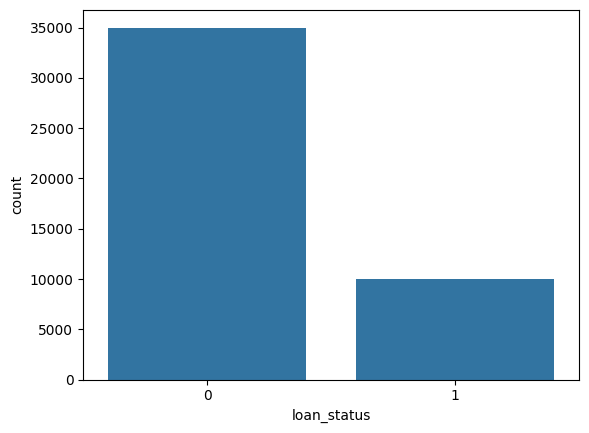

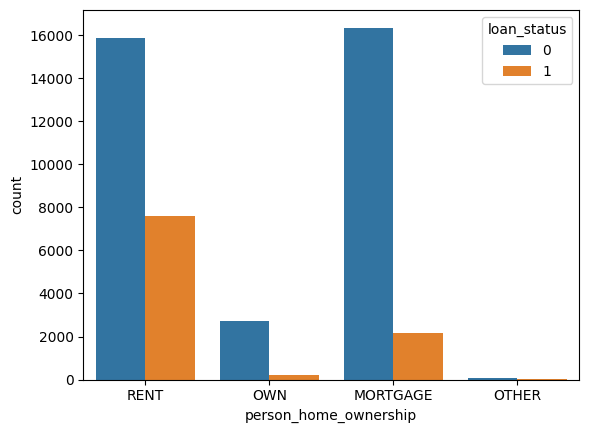

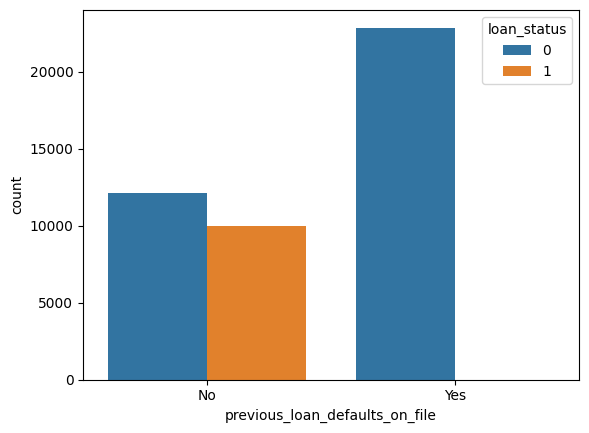

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_status', data=df)
plt.show()

sns.countplot(x='person_home_ownership', hue='loan_status', data=df)
plt.show()

sns.countplot(x='previous_loan_defaults_on_file', hue='loan_status', data=df)
plt.show()

In [10]:
print(df.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [11]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [12]:
X = pd.get_dummies(X, drop_first=True)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      6990
           1       0.63      0.91      0.74      2010

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.82      9000
weighted avg       0.89      0.86      0.87      9000

AUC-ROC: 0.9525


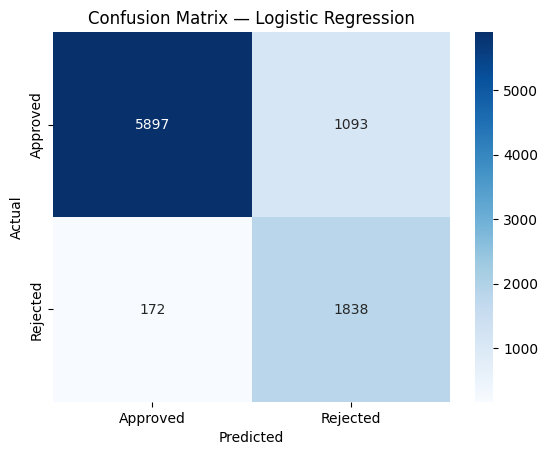

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("AUC-ROC:", round(roc_auc_score(y_test, y_proba), 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved', 'Rejected'])
plt.title("Confusion Matrix — Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

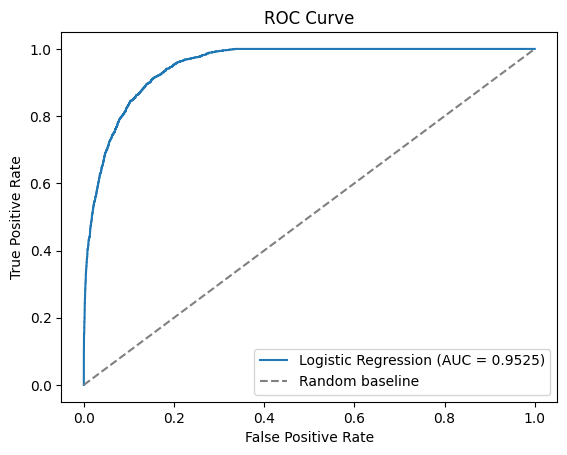

In [16]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.4f})")
plt.plot([0,1],[0,1],'--', color='gray', label='Random baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [34]:
def risk_engine(proba):
    risk = 1 - proba  # flip: approval prob → risk score
    if risk < 0.3:
        return "APPROVE"
    elif risk < 0.7:
        return "REVIEW"
    else:
        return "REJECT"

# Test on first 10 applicants
for i, prob in enumerate(y_proba[:10]):
    risk = 1 - prob
    decision = risk_engine(prob)
    print(f"Applicant {i+1}: Approval Prob={prob:.2f} | Risk={risk:.2f} → {decision}")

Applicant 1: Approval Prob=0.12 | Risk=0.88 → REJECT
Applicant 2: Approval Prob=0.00 | Risk=1.00 → REJECT
Applicant 3: Approval Prob=0.89 | Risk=0.11 → APPROVE
Applicant 4: Approval Prob=0.00 | Risk=1.00 → REJECT
Applicant 5: Approval Prob=0.95 | Risk=0.05 → APPROVE
Applicant 6: Approval Prob=0.07 | Risk=0.93 → REJECT
Applicant 7: Approval Prob=0.00 | Risk=1.00 → REJECT
Applicant 8: Approval Prob=0.93 | Risk=0.07 → APPROVE
Applicant 9: Approval Prob=0.74 | Risk=0.26 → APPROVE
Applicant 10: Approval Prob=0.92 | Risk=0.08 → APPROVE


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', 
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("AUC-ROC:", round(roc_auc_score(y_test, y_proba_rf), 4))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      6990
           1       0.90      0.76      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000

AUC-ROC: 0.9743


In [19]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Rudraksh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [20]:
from xgboost import XGBClassifier

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(scale_pos_weight=scale_pos, n_estimators=100,
                     random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("AUC-ROC:", round(roc_auc_score(y_test, y_proba_xgb), 4))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      6990
           1       0.78      0.90      0.83      2010

    accuracy                           0.92      9000
   macro avg       0.87      0.91      0.89      9000
weighted avg       0.93      0.92      0.92      9000

AUC-ROC: 0.9782


In [21]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [
        round(roc_auc_score(y_test, y_proba), 4),
        round(roc_auc_score(y_test, y_proba_rf), 4),
        round(roc_auc_score(y_test, y_proba_xgb), 4)
    ],
    'F1 - Not Approved': [
        round(classification_report(y_test, y_pred, output_dict=True)['0']['f1-score'], 4),
        round(classification_report(y_test, y_pred_rf, output_dict=True)['0']['f1-score'], 4),
        round(classification_report(y_test, y_pred_xgb, output_dict=True)['0']['f1-score'], 4)
    ],
    'F1 - Approved': [
        round(classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'], 4),
        round(classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score'], 4),
        round(classification_report(y_test, y_pred_xgb, output_dict=True)['1']['f1-score'], 4)
    ]
}

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

              Model  AUC-ROC  F1 - Not Approved  F1 - Approved
Logistic Regression   0.9525             0.9031         0.7440
      Random Forest   0.9743             0.9549         0.8263
            XGBoost   0.9782             0.9466         0.8313


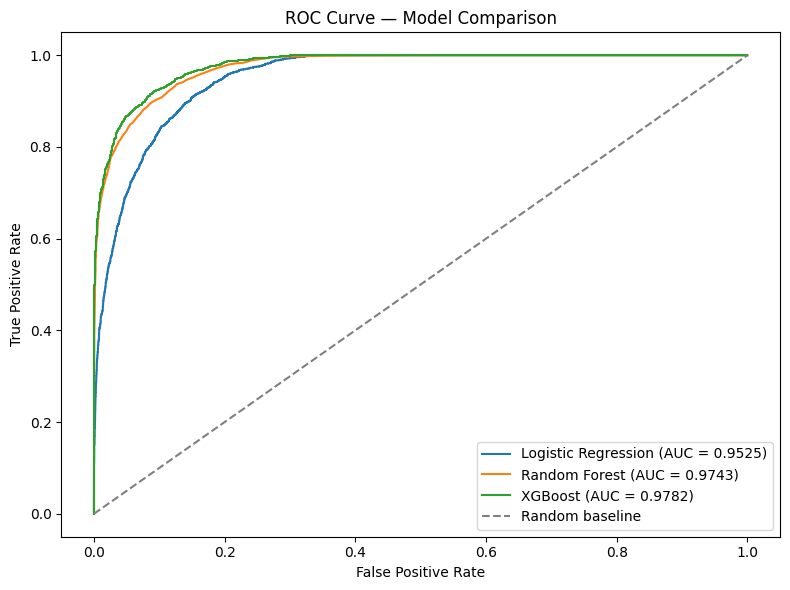

In [22]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for proba, name in [(y_proba, 'Logistic Regression'), 
                     (y_proba_rf, 'Random Forest'),
                     (y_proba_xgb, 'XGBoost')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1],[0,1],'--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

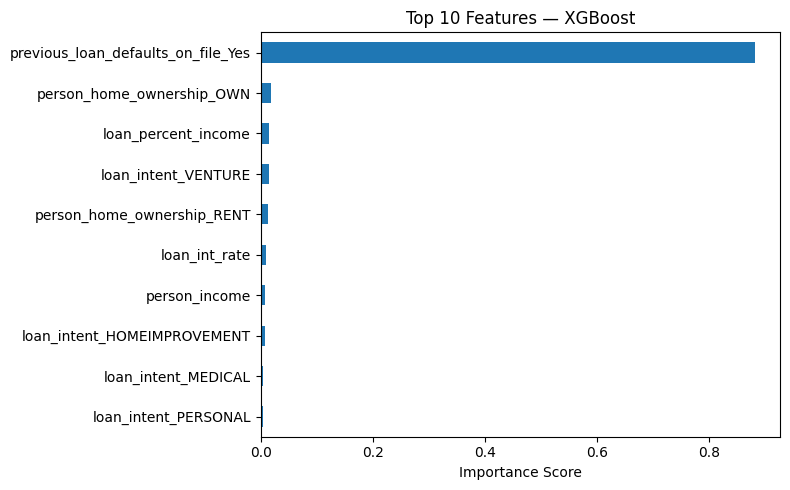

In [23]:
importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
importance.sort_values().tail(10).plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Features — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [24]:
pip install numpy scipy scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Rudraksh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [25]:

pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Rudraksh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [26]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("Done — SHAP ready")

SHAP values shape: (9000, 22)
Done — SHAP ready


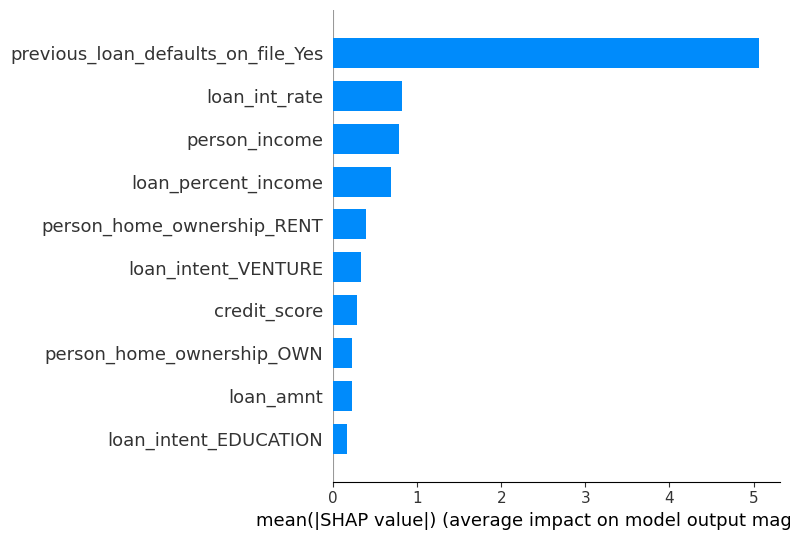

In [27]:
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10)

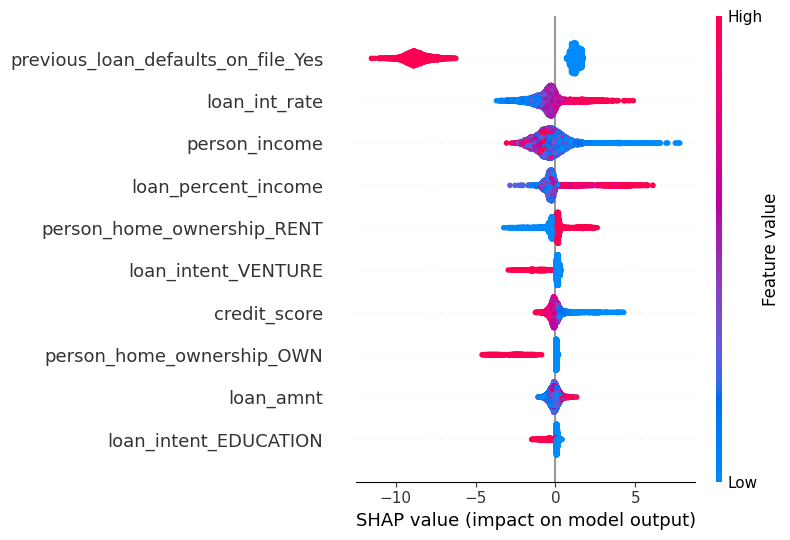

In [28]:
shap.summary_plot(shap_values, X_test, max_display=10)

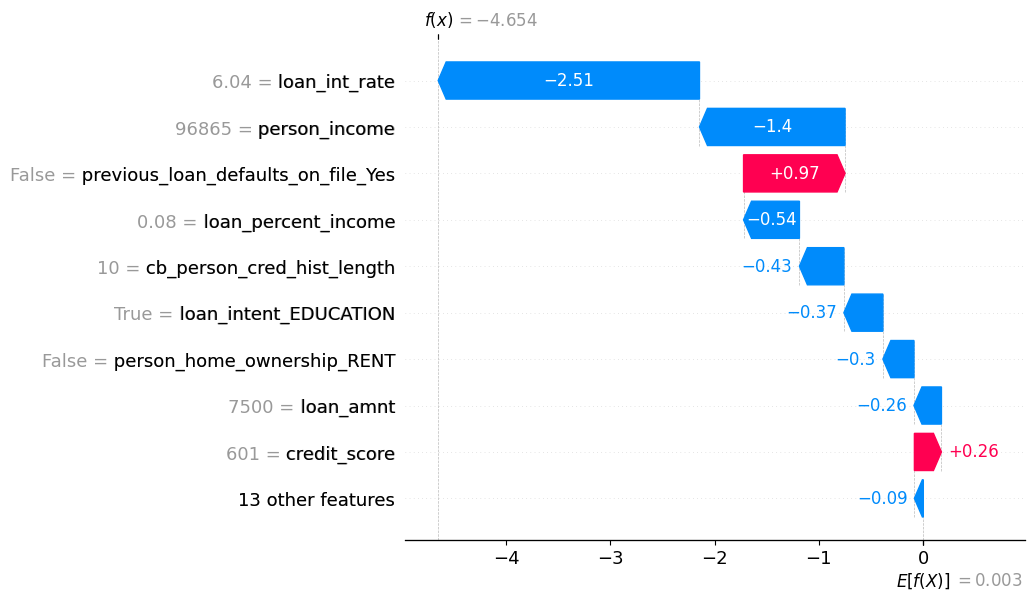

In [29]:
# Explain applicant at index 0
idx = 0
shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx],
    feature_names=X_test.columns.tolist()
))

In [32]:
def explain_decision(idx):
    prob = xgb.predict_proba(X_test.iloc[[idx]])[0][1]
    risk = 1 - prob  # convert approval prob → risk score
    shap_row = shap_values[idx]
    feature_names = X_test.columns.tolist()

    top_idx = abs(shap_row).argsort()[-3:][::-1]

    if risk < 0.3:
        decision = "APPROVED"
    elif risk < 0.7:
        decision = "FLAGGED FOR REVIEW"
    else:
        decision = "REJECTED"

    print(f"Applicant {idx+1}")
    print(f"Approval Probability : {prob:.2f}")
    print(f"Risk Score           : {risk:.2f}")
    print(f"Decision             : {decision}")
    print(f"Top reasons:")
    for i in top_idx:
        impact = shap_row[i]
        arrow = "pushes toward REJECT" if impact > 0 else "pushes toward APPROVE"
        print(f"  - {feature_names[i]}: {arrow} (impact: {impact:+.3f})")

for i in range(5):
    explain_decision(i)
    print()

Applicant 1
Approval Probability : 0.01
Risk Score           : 0.99
Decision             : REJECTED
Top reasons:
  - loan_int_rate: pushes toward APPROVE (impact: -2.508)
  - person_income: pushes toward APPROVE (impact: -1.397)
  - previous_loan_defaults_on_file_Yes: pushes toward REJECT (impact: +0.974)

Applicant 2
Approval Probability : 0.00
Risk Score           : 1.00
Decision             : REJECTED
Top reasons:
  - previous_loan_defaults_on_file_Yes: pushes toward APPROVE (impact: -8.936)
  - loan_intent_EDUCATION: pushes toward APPROVE (impact: -0.321)
  - loan_int_rate: pushes toward APPROVE (impact: -0.319)

Applicant 3
Approval Probability : 0.95
Risk Score           : 0.05
Decision             : APPROVED
Top reasons:
  - loan_int_rate: pushes toward REJECT (impact: +1.540)
  - previous_loan_defaults_on_file_Yes: pushes toward REJECT (impact: +1.464)
  - person_income: pushes toward REJECT (impact: +0.646)

Applicant 4
Approval Probability : 0.00
Risk Score           : 1.00
D

In [35]:
pip install anthropic

   ---------------------------------------- 0.0/627.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/627.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/627.5 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/627.5 kB ? eta -:--:--
   ---------------------------------------- 627.5/627.5 kB 1.9 MB/s eta 0:00:00

   ---------- ----------------------------- 1/4 [docstring-parser]
   ---------- ----------------------------- 1/4 [docstring-parser]
   ---------- ----------------------------- 1/4 [docstring-parser]
   ---------- ----------------------------- 1/4 [docstring-parser]
   ---------- ----------------------------- 1/4 [docstring-parser]
   -------------------- ------------------- 2/4 [distro]
   -------------------- ------------------- 2/4 [distro]
   -------------------- ------------------- 2/4 [distro]
   ------------------------------ --------- 3/4 [anthropic]
   ------------------------------ --------- 3/4 [anthropic]
   ----


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Rudraksh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [37]:
pip install groq

Note: you may need to restart the kernel to use updated packages.Collecting groq




[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Rudraksh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [38]:
from groq import Groq

client_groq = Groq(api_key="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")

# Test connection
response = client_groq.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": "Say: API connected successfully"}],
    max_tokens=20
)
print(response.choices[0].message.content)

API connected successfully.


In [39]:
def get_llm_explanation(idx):
    prob = xgb.predict_proba(X_test.iloc[[idx]])[0][1]
    risk = 1 - prob
    shap_row = shap_values[idx]
    feature_names = X_test.columns.tolist()

    if risk < 0.3:
        decision = "APPROVED"
    elif risk < 0.7:
        decision = "FLAGGED FOR REVIEW"
    else:
        decision = "REJECTED"

    top_idx = abs(shap_row).argsort()[-3:][::-1]
    reasons = []
    for i in top_idx:
        arrow = "increases risk" if shap_row[i] > 0 else "decreases risk"
        reasons.append(
            f"{feature_names[i]} = {X_test.iloc[idx][feature_names[i]]:.2f} ({arrow})"
        )

    prompt = f"""You are a loan officer AI assistant at a bank.

A loan application has been analyzed by our risk model:

- Decision: {decision}
- Approval Probability: {prob:.0%}
- Risk Score: {risk:.0%}
- Top 3 factors:
  1. {reasons[0]}
  2. {reasons[1]}
  3. {reasons[2]}

Write a clear, professional 3-4 sentence explanation for the applicant.
- If APPROVED: be positive, mention key strengths
- If REJECTED: be empathetic, explain reasons, suggest improvements
- If FLAGGED FOR REVIEW: explain it needs human review and why
- Do NOT use technical terms like SHAP, XGBoost, model, features
- Write as if speaking directly to the applicant"""

    response = client_groq.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300
    )

    explanation = response.choices[0].message.content

    print(f"{'='*60}")
    print(f"Applicant {idx+1}")
    print(f"Decision   : {decision}")
    print(f"Risk Score : {risk:.0%}")
    print(f"{'='*60}")
    print("AI Explanation:")
    print(explanation)
    print()

# Run on 3 applicants
for i in [0, 2, 4]:
    get_llm_explanation(i)

Applicant 1
Decision   : REJECTED
Risk Score : 99%
AI Explanation:
I regret to inform you that your loan application has been rejected. Although you have a stable income and the loan's interest rate is relatively favorable, our review process has identified some concerns regarding your credit history, specifically the presence of previous loan defaults. To improve your chances of approval in the future, I recommend taking steps to address these past issues and rebuilding your credit profile. Please don't hesitate to contact us if you'd like to discuss ways to strengthen your application for future consideration.

Applicant 3
Decision   : APPROVED
Risk Score : 5%
AI Explanation:
I am pleased to inform you that your loan application has been approved with a high approval probability of 95%. Although our analysis did identify some areas of consideration, such as the interest rate and your personal income, your overall financial profile demonstrates sufficient strength to support loan repa